In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Multi-class Classification (Iris / Breast Cancer / Digits)
Algorithm       : Algorithm: Multi-Layer Perceptron (MLP) + SGD with Momentum – from scratch

Description     : Manual implementation of a 2-hidden-layer Multi-Layer Perceptron 
                  for multi-class classification using Softmax output and 
                  SGD with Momentum optimizer.
                  Part of the comprehensive Deep Learning course.
                  SGD with Momentum: accelerates gradient descent 
                  by adding a fraction of the previous update (velocity) to the current gradient.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split 
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader

In [76]:
class MLP():
     def __init__(self,n_features,n_hidden1,n_hidden2,n_out,lr=0.1,alpha=0.8,wrate=1):
          self.w1= torch.randn(n_hidden1,n_features+1)*wrate
          self.w2= torch.randn(n_hidden2,n_hidden1+1)*wrate
          self.w3= torch.randn(n_out,n_hidden2+1)*wrate
          self.v1= torch.zeros_like(self.w1)
          self.v2= torch.zeros_like(self.w2)
          self.v3= torch.zeros_like(self.w3)
          
          self.lr= lr
          self.alpha= alpha
          self.n_features=n_features
          self.n_hidden1=n_hidden1
          self.n_hidden2=n_hidden2
          self.n_out=n_out
          
     def __call__(self, data):
          y_pred= self.forward(data)
          return y_pred
              
     def forward(self,data):
          w1= self.w1
          w2= self.w2
          w3= self.w3
          # add bias
          data= torch.cat((-torch.ones(data.size(0),1),data),dim=1) 
          # farward pass
          v1= torch.matmul(w1,data.T)# (2x3) x (3x1) = 2x1
          y1= torch.tanh(v1)
          # add bias
          y1= torch.cat((-torch.ones(1,y1.size(1)),y1),dim=0)
          
          v2= torch.matmul(w2,y1)
          y2= torch.tanh(v2)
          # add bias
          y2= torch.cat((-torch.ones(1,y2.size(1)),y2),dim=0)
          
          v3= torch.matmul(w3,y2)#noutxn_sample
          y3= torch.softmax(v3,dim=0)
          ypred= y3
          
          self.y1=y1
          self.y2= y2
          self.y3= y3
          self.input= data  
          return ypred 
     
     def backward(self,y_true,y_pred):
          lr= self.lr
          alpha= self.alpha
          w1= self.w1
          w2= self.w2
          w3= self.w3
          
          v1= self.v1
          v2= self.v2
          v3= self.v3
          
          input= self.input
          y1= self.y1
          y2= self.y2
          y3= self.y3
          
          y_true= y_true.T
          # adjust output layer weights
          delta3= y_true-y_pred
          dw3= lr*torch.matmul(delta3,y2.T) 
          v3= alpha*v3 + dw3
          
          w3= w3+v3 
          # adjust hidden layer weights
          gd2= self.g_tanh(y2)
          delta2= (gd2) * torch.matmul(w3.T,delta3)
          delta2= delta2[1:,:] 
          dw2= lr*torch.matmul(delta2,y1.T) 
          v2= alpha*v2 + dw2
          
          w2= w2+v2
          
          gd1= self.g_tanh(y1)
          delta1= (gd1) * torch.matmul(w2.T,delta2)
          delta1= delta1[1:,:] 
          dw1= lr*torch.matmul(delta1,input) 
          v1= alpha*v1 + dw1
          
          w1= w1+v1
          
          self.w1= w1
          self.w2= w2
          self.w3= w3
          self.v1= v1
          self.v2= v2
          self.v3= v3
     
     def mse(self,y_true,y_pred):
          y_true= y_true.T
          e= y_true-y_pred
          return torch.mean(e**2)
     
     def g_tanh(self,y):
          return (1-y**2)
     
     def g_sigmoid(self,y):
          return y*(1-y)
     
     def g_relu(self,y):
          yhat= (y>0).type(torch.float32)
          return yhat
     
     def g_linear(self,y):
          return torch.ones(y.size())

In [77]:
#%% load dataset 
ds= datasets.load_digits()
# ds= datasets.load_breast_cancer()
# ds= datasets.load_iris()
data= ds.data
target= ds.target

#%% split data into traind and test
data_train,data_test,d_train,d_test= train_test_split(
     data,target,train_size=0.7,random_state=1)
# standardize
scaler= prep.StandardScaler().fit(data_train)
data_train= scaler.transform(data_train)
data_test= scaler.transform(data_test)
#%% convert to tensor
data_train= torch.from_numpy(data_train).type(torch.float32)
d_train= torch.from_numpy(d_train).type(torch.float32)

data_test= torch.from_numpy(data_test).type(torch.float32)
d_test= torch.from_numpy(d_test).type(torch.float32)

n_out= torch.unique(d_train).numel()
d_train_oneHot=(d_train.reshape(-1,1)==torch.arange(0,n_out).reshape(1,-1)).type(torch.float32)
#% build data loader 
ds= TensorDataset(data_train,d_train_oneHot)
train_loader= DataLoader(ds,batch_size=32,shuffle=True)


MSE(0): 0.066779
MSE(50): 0.000008
MSE(100): 0.000001


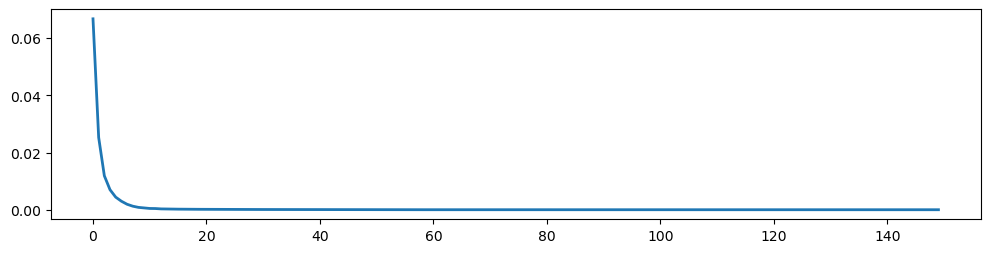

In [78]:
#%% train Neural Network
torch.manual_seed(0)
lr=0.01
alpha=0.2

n_hid1= 30
n_hid2= 10
n_out= n_out
n_features= data_train.size(1)

# mdl= NeuralNetwork1(n_features, n_hid1,n_out,lr,wrate=1)
mdl= MLP(n_features, n_hid1,n_hid2,n_out,lr,alpha,wrate=0.1)
cost=[]
epoch=150
for iter in range(epoch):
     er=[]
     for xbatch,ybatch in train_loader:
          # farward pass
          ypred= mdl(xbatch)
          # backward pass 
          mdl.backward(ybatch,ypred) 
          er.append(mdl.mse(ybatch,ypred)) 

     loss= torch.mean(torch.tensor(er))
     cost.append(loss)
     if iter%50==0:
          print(f'MSE({iter}): {cost[iter]:.6f}')

cost=torch.tensor(cost)
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(cost,linewidth=2)
plt.show()

Total accuracy:96.111%


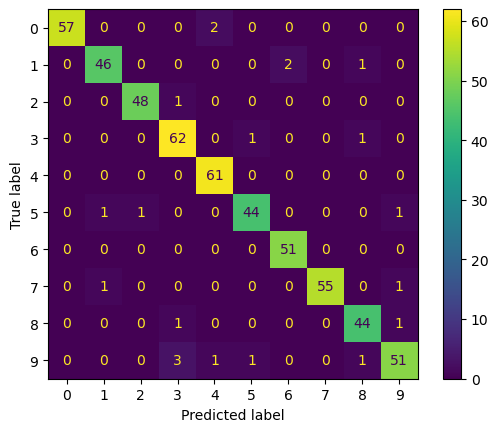

In [79]:
#%% test trained Neural Network
ypred= mdl(data_test)
ypred= torch.argmax(ypred.T,dim=1)
#%% validate your Neural Network
C= metrics.confusion_matrix(d_test.flatten(),ypred.flatten())
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

disp= metrics.ConfusionMatrixDisplay(C)
disp.plot()
plt.show()